In [ ]:
#week1

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("data_ml.csv")

print("Original shape:", df.shape)
print("Missing values before processing:\n", df.isnull().sum())

target_col = df.columns[-1]
X = df.drop(columns=[target_col])
y = df[target_col]

num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns

X_mean = X.copy()
for col in num_cols:
    X_mean[col] = X_mean[col].fillna(X_mean[col].mean())

print("\nMissing values after Mean Imputation:\n", X_mean[num_cols].isnull().sum())

X_class_mean = X.copy()
for col in num_cols:
    X_class_mean[col] = X_class_mean.groupby(y)[col].transform(
        lambda x: x.fillna(x.mean())
    )

print("\nMissing values after Class Mean Imputation:\n",
      X_class_mean[num_cols].isnull().sum())

X_encoded = X_mean.copy()

for col in cat_cols:
    if X_encoded[col].nunique() == 2:
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

print("\nAfter Label Encoding (first 5 rows):")
print(X_encoded.head())

nominal_cols = [c for c in cat_cols if X[c].nunique() > 2]
X_encoded = pd.get_dummies(X_encoded, columns=nominal_cols, drop_first=True)

print("\nAfter One-Hot Encoding (first 5 rows):")
print(X_encoded.head())
print("Shape after encoding:", X_encoded.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

Original shape: (16104, 11)
Missing values before processing:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Missing values after Mean Imputation:
 step              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

Missing values after Class Mean Imputation:
 step              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

After Label Encoding (first 5 rows):
   step     type     amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0    10  PAYMENT    4491.22  C1177286099       16183.00        11691.78   
1    13  CASH_IN  307220.57   C910746626     1632842.98      1940063.55   
2    13  CASH_IN   48389.40   C902502402     2765

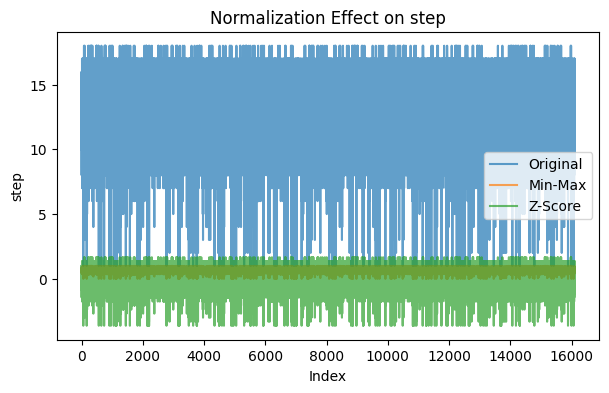

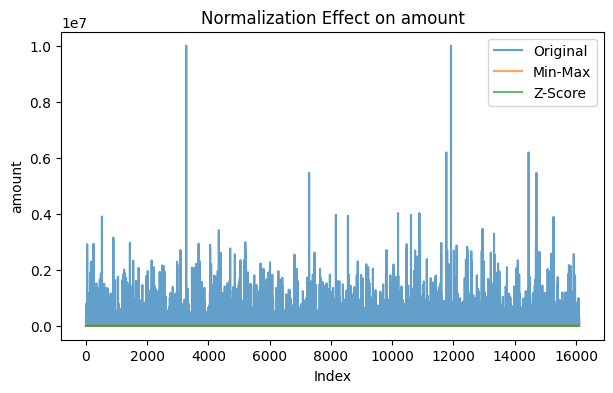

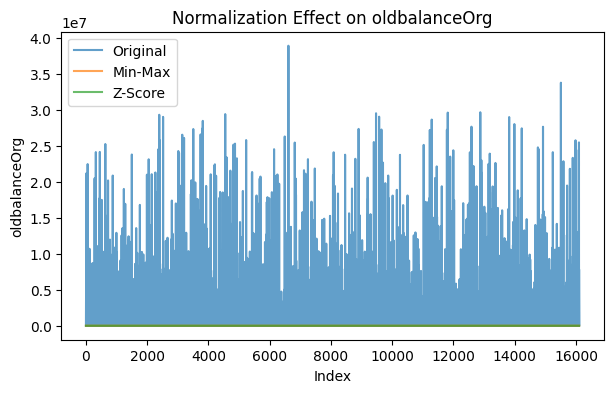

✔ All preprocessing, normalization, splitting, and visualization completed.


In [ ]:
# ==============================
# SINGLE CELL – COMPLETE SOLUTION
# ==============================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt

# ------------------------------
# Load dataset
# ------------------------------
df = pd.read_csv("data_ml.csv")

# ------------------------------
# 1(a) Separate features & target
# ------------------------------
target_col = df.columns[-1]     # last column as target
X = df.drop(columns=[target_col])
y = df[target_col]

# ------------------------------
# Identify column types
# ------------------------------
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns

# ------------------------------
# 1(b) Missing value handling
# ------------------------------
# Mean Imputation
X_mean = X.copy()
for col in num_cols:
    X_mean[col] = X_mean[col].fillna(X_mean[col].mean())

# Class Mean Imputation
X_class_mean = X.copy()
for col in num_cols:
    X_class_mean[col] = X_class_mean.groupby(y)[col].transform(
        lambda x: x.fillna(x.mean())
    )

# ------------------------------
# 1(c) Encoding
# ------------------------------
X_encoded = X_mean.copy()

# Label Encoding (binary categorical)
for col in cat_cols:
    if X_encoded[col].nunique() == 2:
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

# One-Hot Encoding (nominal categorical)
nominal_cols = [c for c in cat_cols if X[c].nunique() > 2]
X_encoded = pd.get_dummies(X_encoded, columns=nominal_cols, drop_first=True)

# ------------------------------
# 1(d) Train-Test Split (70:30)
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42
)

# ------------------------------
# 2(c) Normalization
# ------------------------------
scalable_cols = X_train.select_dtypes(include=np.number).columns

# Min-Max Normalization
minmax = MinMaxScaler()
X_minmax = X_encoded.copy()
X_minmax[scalable_cols] = minmax.fit_transform(X_minmax[scalable_cols])

# Z-Score Standardization
zscore = StandardScaler()
X_zscore = X_encoded.copy()
X_zscore[scalable_cols] = zscore.fit_transform(X_zscore[scalable_cols])

# ------------------------------
# 2(d) Train-Test Split after normalization
# ------------------------------
X_train_mm, X_test_mm, y_train_mm, y_test_mm = train_test_split(
    X_minmax, y, test_size=0.3, random_state=42
)

X_train_z, X_test_z, y_train_z, y_test_z = train_test_split(
    X_zscore, y, test_size=0.3, random_state=42
)

# ------------------------------
# 2(e) Visualization (3 attributes)
# ------------------------------
plot_cols = scalable_cols[:3]

for col in plot_cols:
    plt.figure(figsize=(7,4))
    plt.plot(X_encoded[col].values, label="Original", alpha=0.7)
    plt.plot(X_minmax[col].values, label="Min-Max", alpha=0.7)
    plt.plot(X_zscore[col].values, label="Z-Score", alpha=0.7)
    plt.title(f"Normalization Effect on {col}")
    plt.xlabel("Index")
    plt.ylabel(col)
    plt.legend()
    plt.show()

print("✔ All preprocessing, normalization, splitting, and visualization completed.")

In [ ]:
#week2

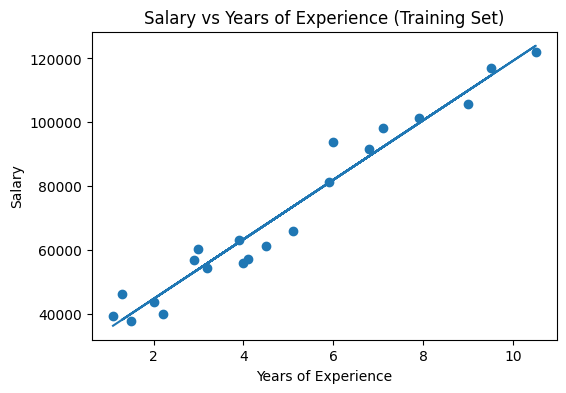

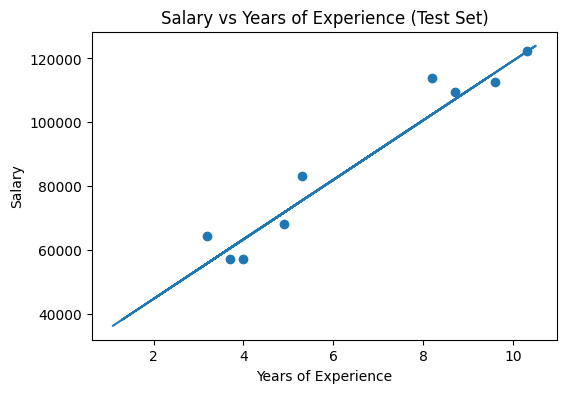

Slope (Coefficient): 9339.081723815198
Intercept: 25918.438334893202


In [ ]:
# =========================================
# SIMPLE LINEAR REGRESSION – SINGLE CELL
# Dataset: Salary_Data.csv
# =========================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# -----------------------------------------
# Load Dataset
# -----------------------------------------
df = pd.read_csv("Salary_Data.csv")
# -----------------------------------------
# a) Identify Independent & Dependent Variables
# -----------------------------------------
X = df[['YearsExperience']]   # Independent variable
y = df['Salary']              # Dependent variable

# -----------------------------------------
# b) Split dataset (70:30)
# -----------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -----------------------------------------
# c) Fit Simple Linear Regression model
# -----------------------------------------
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# -----------------------------------------
# d) Predict test set results
# -----------------------------------------
y_pred = regressor.predict(X_test)

# -----------------------------------------
# e) Visualization
# -----------------------------------------

# Training set results
plt.figure(figsize=(6,4))
plt.scatter(X_train, y_train)
plt.plot(X_train, regressor.predict(X_train))
plt.title("Salary vs Years of Experience (Training Set)")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

# Test set results
plt.figure(figsize=(6,4))
plt.scatter(X_test, y_test)
plt.plot(X_train, regressor.predict(X_train))
plt.title("Salary vs Years of Experience (Test Set)")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

print("Slope (Coefficient):", regressor.coef_[0])
print("Intercept:", regressor.intercept_)

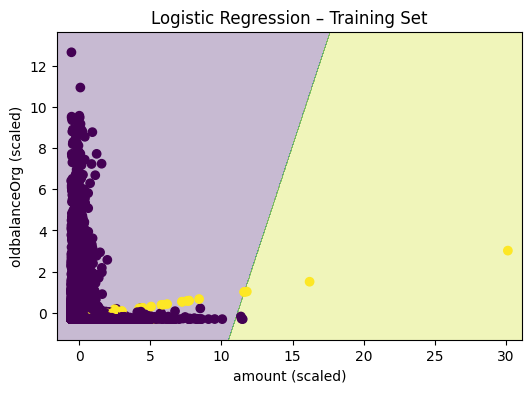

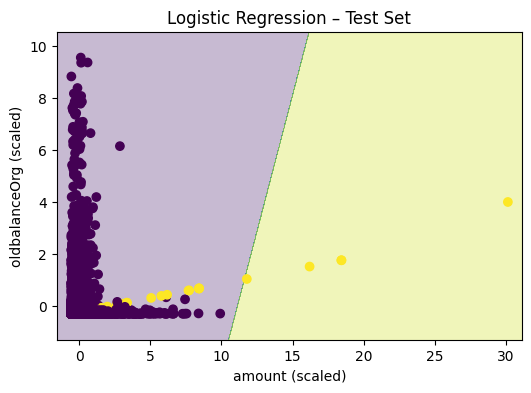

Logistic Regression completed successfully.


In [ ]:
# ==================================================
# LOGISTIC REGRESSION WITH DECISION BOUNDARY
# Dataset: data_ml.csv
# ==================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# --------------------------------------------------
# Load dataset
# --------------------------------------------------
df = pd.read_csv("data_ml.csv")

# --------------------------------------------------
# a) Identify independent & dependent variables
# (Using two numerical attributes for visualization)
# --------------------------------------------------
X = df[['amount', 'oldbalanceOrg']]   # Independent variables
y = df['isFraud']                     # Dependent variable

# --------------------------------------------------
# b) Split dataset (70:30)
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# --------------------------------------------------
# c) Feature Scaling
# --------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --------------------------------------------------
# d) Fit Logistic Regression model
# --------------------------------------------------
classifier = LogisticRegression()
classifier.fit(X_train_scaled, y_train)

# --------------------------------------------------
# e) Predict test set results
# --------------------------------------------------
y_pred = classifier.predict(X_test_scaled)

# --------------------------------------------------
# f) Decision Boundary Visualization
# --------------------------------------------------
def plot_decision_boundary(X, y, model, title):
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx1, xx2 = np.meshgrid(
        np.arange(x1_min, x1_max, 0.02),
        np.arange(x2_min, x2_max, 0.02)
    )

    Z = model.predict(np.c_[xx1.ravel(), xx2.ravel()])
    Z = Z.reshape(xx1.shape)

    plt.figure(figsize=(6,4))
    plt.contourf(xx1, xx2, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title(title)
    plt.xlabel("amount (scaled)")
    plt.ylabel("oldbalanceOrg (scaled)")
    plt.show()

# Training set decision boundary
plot_decision_boundary(
    X_train_scaled, y_train.values,
    classifier,
    "Logistic Regression – Training Set"
)

# Test set decision boundary
plot_decision_boundary(
    X_test_scaled, y_test.values,
    classifier,
    "Logistic Regression – Test Set"
)

print("Logistic Regression completed successfully.")

In [ ]:
#week3

In [ ]:
# ==================================================
# NAIVE BAYES CLASSIFICATION – SINGLE CELL
# Dataset: data_ml.csv
# ==================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score

# --------------------------------------------------
# Load dataset
# --------------------------------------------------
dataset = pd.read_csv("data_ml.csv")

# --------------------------------------------------
# a) Identify Independent & Dependent Attributes
# --------------------------------------------------
target_col = 'isFraud'                 # Dependent attribute
X = dataset.drop(columns=[target_col]) # Independent attributes
y = dataset[target_col]
# --------------------------------------------------
# Identify numerical & categorical columns
# --------------------------------------------------
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns
# --------------------------------------------------
# b) Handle missing values (Mean Imputation)
# --------------------------------------------------
for col in num_cols:
    X[col] = X[col].fillna(X[col].mean())
# --------------------------------------------------
# c) Encode categorical attributes
# --------------------------------------------------
# Label Encoding for binary categorical variables
for col in cat_cols:
    if X[col].nunique() == 2:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

# One-Hot Encoding for nominal categorical variables
nominal_cols = [col for col in cat_cols if X[col].nunique() > 2]
X = pd.get_dummies(X, columns=nominal_cols, drop_first=True)

# --------------------------------------------------
# d) Train-Test Split (70:30)
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# --------------------------------------------------
# e) Train Naive Bayes Classifier
# --------------------------------------------------
nb = GaussianNB()
nb.fit(X_train, y_train)

# --------------------------------------------------
# f) Predict Test Set Results
# --------------------------------------------------
y_pred = nb.predict(X_test)

# --------------------------------------------------
# Evaluation
# --------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print("Confusion Matrix:\n", cm)
print("Accuracy:", acc)

Confusion Matrix:
 [[4457  299]
 [  56   20]]
Accuracy: 0.9265314569536424


In [ ]:
X = dataset[['oldbalanceOrg', 'newbalanceOrig', 'amount']].values
y = dataset['isFraud'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

for metric in ['euclidean', 'manhattan']:
    knn = KNeighborsClassifier(n_neighbors=3, metric=metric)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    print(f"Accuracy ({metric}, k=3):", accuracy_score(y_test, y_pred))

k_values = [1, 3, 5, 7]
metrics = ['euclidean', 'manhattan']

for metric in metrics:
    print(f"\nDistance Metric: {metric}")
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print(f"k = {k}, Accuracy = {acc:.4f}")


Confusion Matrix:
 [[4633  140]
 [  47   12]]
Accuracy (euclidean, k=3): 0.9855132450331126
Accuracy (manhattan, k=3): 0.9875827814569537

Distance Metric: euclidean
k = 1, Accuracy = 0.9907
k = 3, Accuracy = 0.9855
k = 5, Accuracy = 0.9874
k = 7, Accuracy = 0.9882

Distance Metric: manhattan
k = 1, Accuracy = 0.9917
k = 3, Accuracy = 0.9876
k = 5, Accuracy = 0.9876
k = 7, Accuracy = 0.9880


In [ ]:
#week4


First 5 rows:
  Day   Outlook Temperature Humidity    Wind PlayTennis
0  D1     sunny         hot     high    weak         no
1  D2     sunny         hot     high  strong         no
2  D3  overcast         hot     high    weak        yes
3  D4      rain        mild     high    weak        yes
4  D5      rain        cool   normal    weak        yes

Missing values:
Day            0
Outlook        0
Temperature    0
Humidity       0
Wind           0
PlayTennis     0
dtype: int64


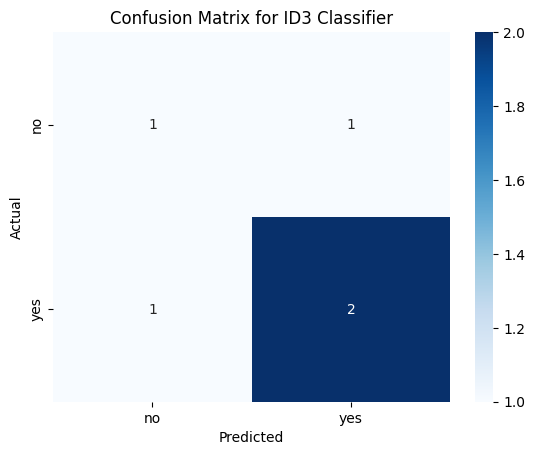

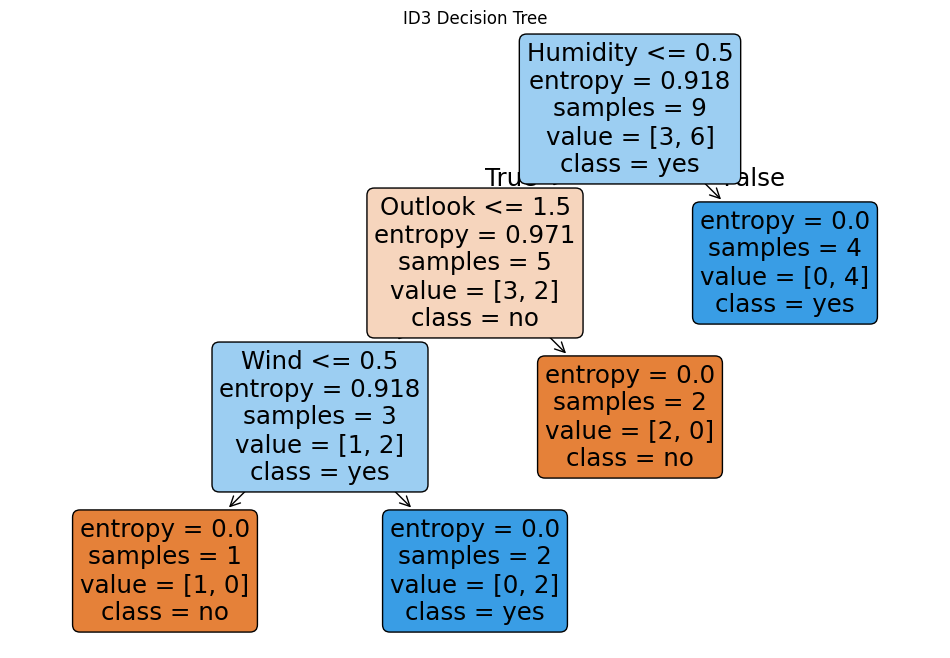

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('tennis.csv')
print("\nFirst 5 rows:")
print(df.head())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import numpy as np

X = df.drop(columns=['Day', 'PlayTennis'])
y = df['PlayTennis']

numerical_cols = X.select_dtypes(include=['number']).columns
if len(numerical_cols) > 0:
    for col in numerical_cols:
        X[col].fillna(X[col].mean(), inplace=True)

le = LabelEncoder()
X_encoded = X.apply(le.fit_transform)
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.30, random_state=42)

clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
#print(classification_report(y_test, y_pred, target_names=le.classes_))

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = np.array([[1, 1], [1, 2]])
classes = ['no', 'yes']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix for ID3 Classifier')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png')

from sklearn.tree import DecisionTreeClassifier, plot_tree

X = df[['Outlook', 'Temperature', 'Humidity', 'Wind']]
y = df['PlayTennis']

# Label Encoding
X_encoded = X.apply(LabelEncoder().fit_transform)
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)

# Split and Train
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.30, random_state=42)
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X_train, y_train)

# Plot Decision Tree
plt.figure(figsize=(12, 8))
plot_tree(clf,
          feature_names=X.columns.tolist(),
          class_names=le_y.classes_.tolist(),
          filled=True,
          rounded=True)
plt.title("ID3 Decision Tree")
plt.savefig('decision_tree.png')

In [ ]:
#svm

Confusion Matrix:
 [[4319  451]
 [   7   55]]
Accuracy Score: 0.9052152317880795


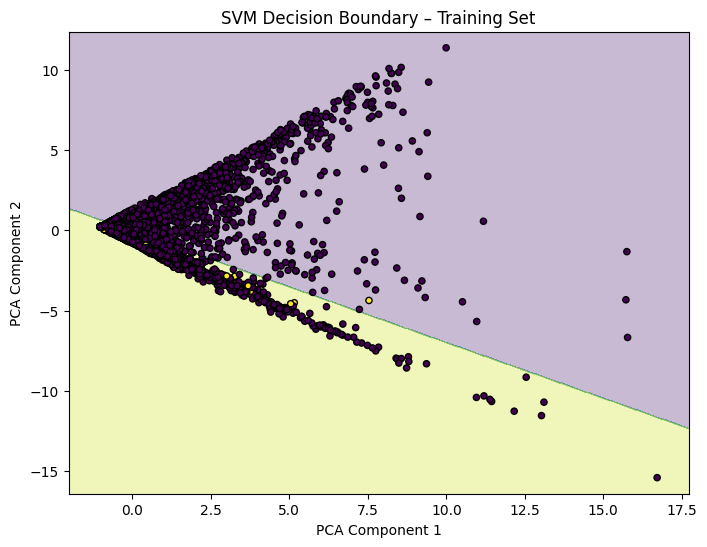

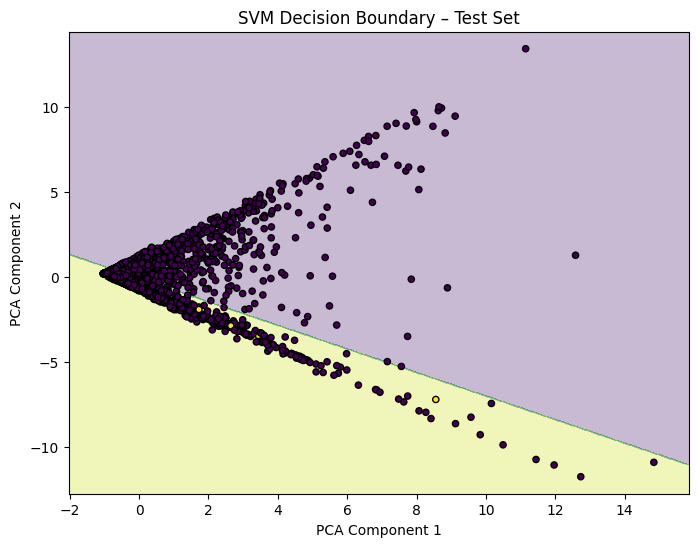

In [ ]:
# ================================
# Support Vector Machine Classifier
# ================================

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.decomposition import PCA

# --------------------------------
# Load the dataset
# --------------------------------
df = pd.read_csv("data_ml.csv")

# --------------------------------
# a) Identify Independent & Dependent Attributes
# --------------------------------
X = df.drop(columns=['isFraud', 'nameOrig', 'nameDest', 'isFlaggedFraud'])
y = df['isFraud']

# --------------------------------
# Identify categorical & numerical columns
# --------------------------------
categorical_cols = ['type']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# --------------------------------
# b) Split dataset into 70:30
# --------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --------------------------------
# c) Feature Scaling & Encoding
# --------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ]
)

# --------------------------------
# d) Train SVM Classifier (Linear Kernel)
# --------------------------------
svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='linear', class_weight='balanced'))
])

svm_pipeline.fit(X_train, y_train)

# --------------------------------
# e) Predict Test Set Results
# --------------------------------
y_pred = svm_pipeline.predict(X_test)

# --------------------------------
# f) Model Evaluation
# --------------------------------
conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print("Confusion Matrix:\n", conf_matrix)
print("Accuracy Score:", accuracy)

# --------------------------------
# g) Visualize Decision Boundaries using PCA
# --------------------------------

# Transform data
X_train_transformed = svm_pipeline.named_steps['preprocessor'].transform(X_train)
X_test_transformed = svm_pipeline.named_steps['preprocessor'].transform(X_test)

# Reduce to 2D
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_transformed)
X_test_pca = pca.transform(X_test_transformed)

# Train SVM on PCA data
svm_2d = SVC(kernel='linear', class_weight='balanced')
svm_2d.fit(X_train_pca, y_train)

# Decision boundary plotting function
def plot_decision_boundary(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)
    plt.title(title)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.show()

# Training Set Visualization
plot_decision_boundary(
    X_train_pca, y_train, svm_2d,
    "SVM Decision Boundary – Training Set"
)

# Test Set Visualization
plot_decision_boundary(
    X_test_pca, y_test, svm_2d,
    "SVM Decision Boundary – Test Set"
)

In [ ]:
#week5

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# -----------------------------
# a) Load Dataset
# -----------------------------
df = pd.read_csv("data_ml.csv")

selected_columns = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest'
]

df = df[selected_columns + ['isFraud']]
df = df.dropna()

X = df[selected_columns]   # Independent attributes
y = df['isFraud']          # Dependent attribute

print("Dataset shape:", X.shape)

# -----------------------------
# b) Train-Test Split (70:30)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# -----------------------------
# c) Feature Scaling
# -----------------------------
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# d) Train Individual Classifiers
# -----------------------------

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# -----------------------------
# e) Voting Classifier
# -----------------------------

# Hard Voting
hard_vote = VotingClassifier(
    estimators=[('lr', lr), ('dt', dt), ('knn', knn)],
    voting='hard'
)
hard_vote.fit(X_train, y_train)

# Soft Voting
soft_vote = VotingClassifier(
    estimators=[('lr', lr), ('dt', dt), ('knn', knn)],
    voting='soft'
)
soft_vote.fit(X_train, y_train)

# -----------------------------
# f) Predictions
# -----------------------------
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "KNN": knn,
    "Hard Voting": hard_vote,
    "Soft Voting": soft_vote
}

# -----------------------------
# g) Evaluation
# -----------------------------
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    print(f"\n{name}")
    print("Confusion Matrix:")
    print(cm)
    print("Accuracy:", acc)

Dataset shape: (16104, 5)

Logistic Regression
Confusion Matrix:
[[4770    0]
 [  61    1]]
Accuracy: 0.9873758278145696

Decision Tree
Confusion Matrix:
[[4753   17]
 [  27   35]]
Accuracy: 0.9908940397350994

KNN
Confusion Matrix:
[[4761    9]
 [  44   18]]
Accuracy: 0.9890314569536424

Hard Voting
Confusion Matrix:
[[4767    3]
 [  45   17]]
Accuracy: 0.9900662251655629

Soft Voting
Confusion Matrix:
[[4767    3]
 [  45   17]]
Accuracy: 0.9900662251655629



Logistic Regression
Accuracy: 0.9873758278145696


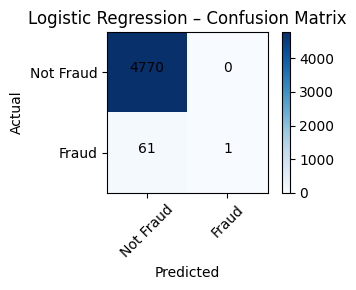


Decision Tree
Accuracy: 0.9908940397350994


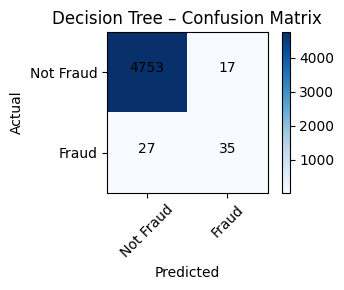


KNN
Accuracy: 0.9890314569536424


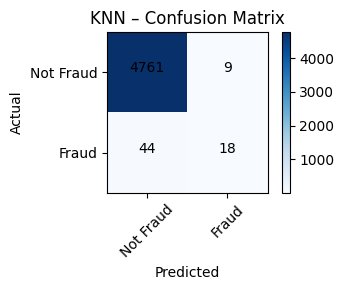


Hard Voting
Accuracy: 0.9900662251655629


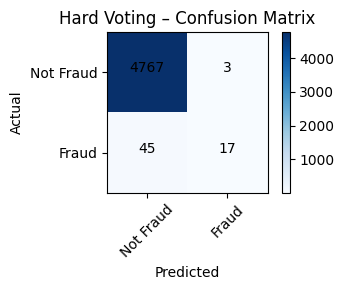


Soft Voting
Accuracy: 0.9900662251655629


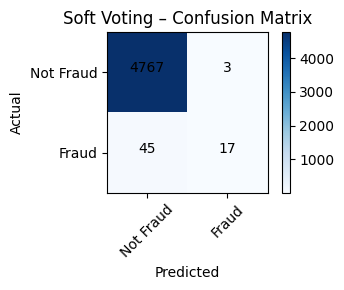

In [ ]:
import matplotlib.pyplot as plt
import itertools

# ---------------------------------
# Function to plot confusion matrix
# ---------------------------------
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(4, 3))
    plt.imshow(cm, cmap='Blues')
    plt.title(title)
    plt.colorbar()

    classes = ['Not Fraud', 'Fraud']
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center")

    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

# ---------------------------------
# Evaluation with plots
# ---------------------------------
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    print(f"\n{name}")
    print("Accuracy:", acc)

    plot_confusion_matrix(cm, f"{name} – Confusion Matrix")

In [ ]:
#week6

In [ ]:
#back propogation

Dataset shape: (16104, 5)
Training samples: 11272
Testing samples: 4832

After SMOTE:
Training samples: 22256
Fraud count: 11128
Normal count: 11128

Confusion Matrix (TP FP / FN TN):

          49             572
          13             4198

Accuracy: 0.878932119205298
Precision: 0.07890499194847021
Recall: 0.7903225806451613


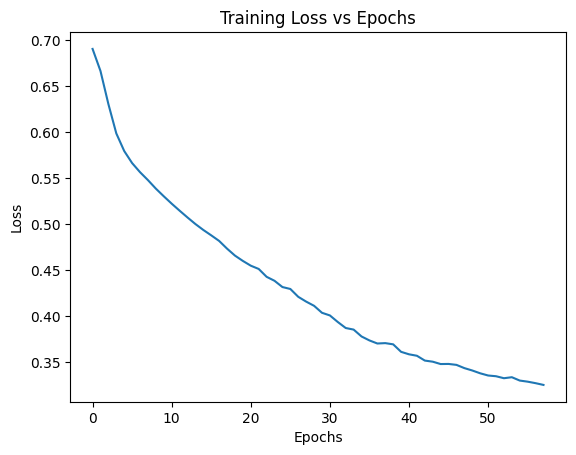

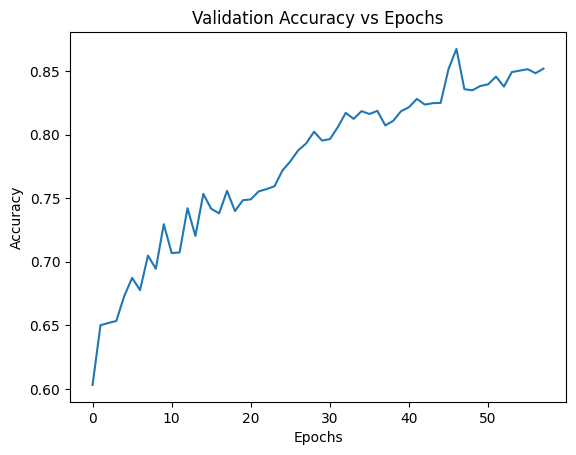

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("data_ml.csv")

features = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest'
]

df = df[features + ['isFraud']]
df = df.dropna()

X = df[features]
y = df['isFraud']

print("Dataset shape:", X.shape)

# -----------------------------
# Feature Scaling
# -----------------------------
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# Train-Test Split (70:30)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# -----------------------------
# Apply SMOTE (Balance Training Data)
# -----------------------------
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print("Training samples:", X_train_res.shape[0])
print("Fraud count:", sum(y_train_res == 1))
print("Normal count:", sum(y_train_res == 0))

# -----------------------------
# ANN Model
# -----------------------------
ann = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    solver='adam',
    max_iter=200,
    learning_rate_init=0.001,
    early_stopping=True,
    validation_fraction=0.2,
    random_state=42
)

# -----------------------------
# Train ANN
# -----------------------------
ann.fit(X_train_res, y_train_res)

# -----------------------------
# Predict Test Set
# -----------------------------
y_pred = ann.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix (TP FP / FN TN):\n")
print(f"          {tp}             {fp}")
print(f"          {fn}             {tn}")

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

# -----------------------------
# Plot Training Loss
# -----------------------------
plt.figure()
plt.plot(ann.loss_curve_)
plt.title("Training Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# -----------------------------
# Plot Validation Accuracy
# -----------------------------
plt.figure()
plt.plot(ann.validation_scores_)
plt.title("Validation Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
#knn

Dataset shape: (16104, 5)


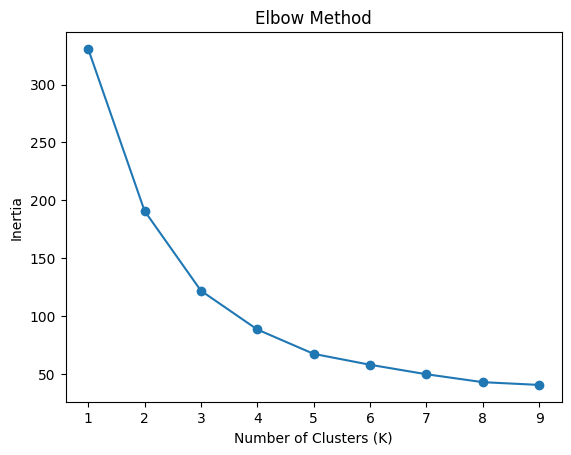

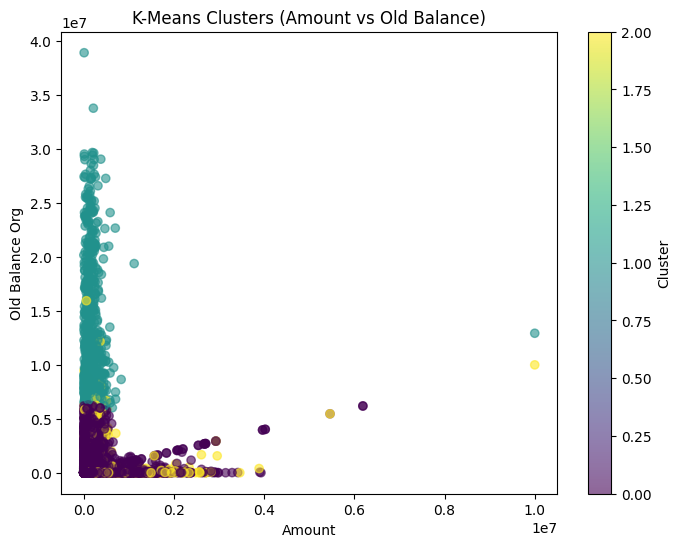


Cluster Distribution:
cluster
0    14569
1      775
2      760
Name: count, dtype: int64

Cluster Means:
                amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
cluster                                                                 
0        170641.050892   3.334975e+05    3.373978e+05    5.349869e+05   
1        175814.861729   1.219215e+07    1.234086e+07    1.409662e+06   
2        436868.369566   7.597193e+05    7.557400e+05    9.159083e+06   

         newbalanceDest  
cluster                  
0          7.183182e+05  
1          1.347955e+06  
2          9.982126e+06  

Cluster vs Fraud Distribution:
isFraud      0    1
cluster            
0        14373  196
1          774    1
2          751    9


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

# -----------------------------
# a) Load Dataset & Select Features
# -----------------------------
df = pd.read_csv("data_ml.csv")

selected_columns = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest'
]

df = df[selected_columns + ['isFraud']]
df = df.dropna()

# Feature matrix (unsupervised → remove target)
X = df[selected_columns]

print("Dataset shape:", X.shape)

# -----------------------------
# Feature Scaling
# -----------------------------
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# b) Determine Optimal K (Elbow Method)
# -----------------------------
inertia = []
k_range = range(1, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure()
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# -----------------------------
# c) Apply KMeans with Optimal K
# (Choose K based on elbow graph, e.g., 3)
# -----------------------------
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# -----------------------------
# d) 2D Visualization
# -----------------------------
plt.figure(figsize=(8,6))
plt.scatter(
    df['amount'],
    df['oldbalanceOrg'],
    c=df['cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.xlabel("Amount")
plt.ylabel("Old Balance Org")
plt.title("K-Means Clusters (Amount vs Old Balance)")
plt.colorbar(label="Cluster")
plt.show()

# -----------------------------
# e) Interpretation Support
# -----------------------------
print("\nCluster Distribution:")
print(df['cluster'].value_counts())

print("\nCluster Means:")
print(df.groupby('cluster')[selected_columns].mean())

print("\nCluster vs Fraud Distribution:")
print(pd.crosstab(df['cluster'], df['isFraud']))